# Statistical Analysis

This notebook performs the statistical analyses for the study:

- Pearson Correlation
- Spearman Correlation
- One-Way ANOVA
- Seasonal ANOVA
- Correlation Heatmap
- Scatter Plots

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import f_oneway

import seaborn as sns

plt.style.use("default")

In [4]:
df = pd.read_csv("../data/processed/master_dataset.csv")

df["date"] = pd.to_datetime(df["date"])

df.head()

,date,daily_mean_tec,ssn,kp_mean,ap_daily,f107_obs,f107_adj,dst_daily_mean
0,2022-01-01,19.980,48.0,2.416625,12.0,93.9,90.8,-11.125000
1,2022-01-02,19.680,27.0,2.041500,9.0,89.0,86.0,-9.708333
2,2022-01-03,18.256,10.0,2.416625,12.0,84.0,81.3,-10.833333
3,2022-01-04,17.548,10.0,1.083250,5.0,85.5,82.7,-10.083333
4,2022-01-05,15.896,23.0,0.625000,2.0,83.7,81.0,-3.583333


# Pearson Correlation

In [8]:
variables = [
    "ssn",
    "kp_mean",
    "ap_daily",
    "f107_obs",
    "f107_adj",
    "dst_daily_mean"
]

pearson_results = []

for var in variables:

    temp = df[["daily_mean_tec", var]].dropna()

    r, p = pearsonr(
        temp["daily_mean_tec"],
        temp[var]
    )

    pearson_results.append({
        "Variable": var,
        "Pearson_r": r,
        "p_value": p
    })

pearson_df = pd.DataFrame(pearson_results)

pearson_df

,Variable,Pearson_r,p_value
0,ssn,0.454624,5.255586e-57
1,kp_mean,0.244856,1.994518e-16
2,ap_daily,0.192305,1.370254e-10
3,f107_obs,0.592868,6.613183e-105
4,f107_adj,0.570423,1.605580e-95
5,dst_daily_mean,-0.243415,3.020766e-16


# Spearman Correlation

In [13]:
spearman_results = []

for var in variables:

    temp = df[["daily_mean_tec", var]].dropna()

    rho, p = spearmanr(
        temp["daily_mean_tec"],
        temp[var]
    )

    spearman_results.append({
        "Variable": var,
        "Spearman_rho": rho,
        "p_value": p
    })

spearman_df = pd.DataFrame(spearman_results)

spearman_df

,Variable,Spearman_rho,p_value
0,ssn,0.435996,4.522732e-52
1,kp_mean,0.202796,1.230106e-11
2,ap_daily,0.195400,6.822575e-11
3,f107_obs,0.580995,7.516726e-100
4,f107_adj,0.556685,3.998675e-90
5,dst_daily_mean,-0.191178,1.761382e-10


# Correlation Heatmap

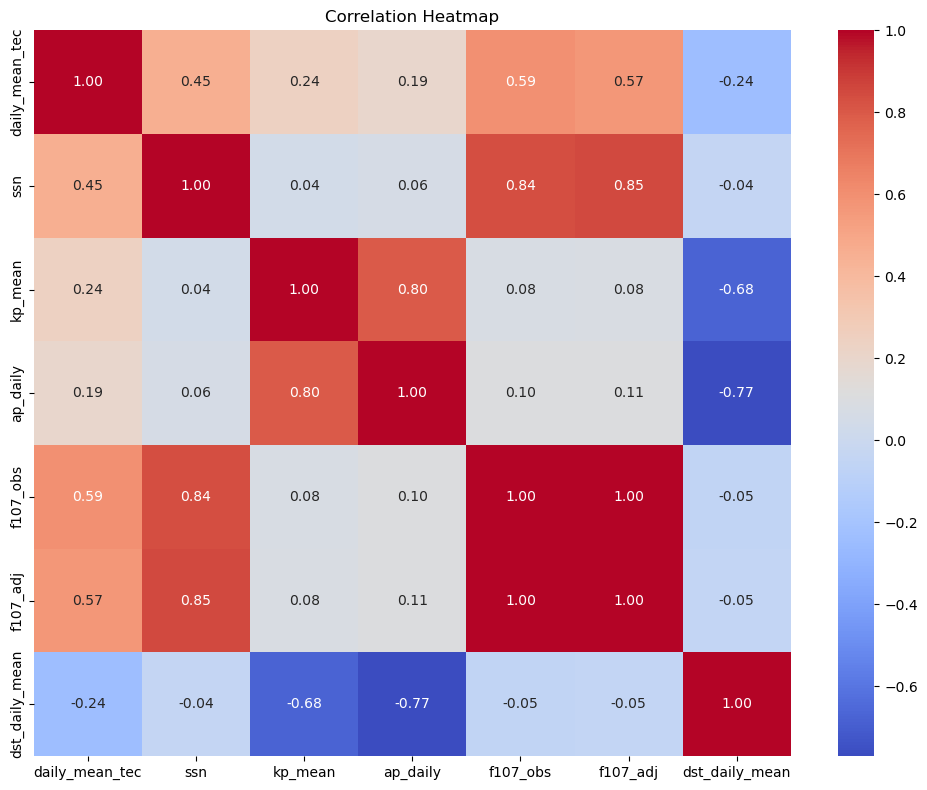

In [16]:
corr = df.drop(columns="date").corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../results/correlation_heatmap.png",
    dpi=300
)

plt.show()

# Scatter Plots

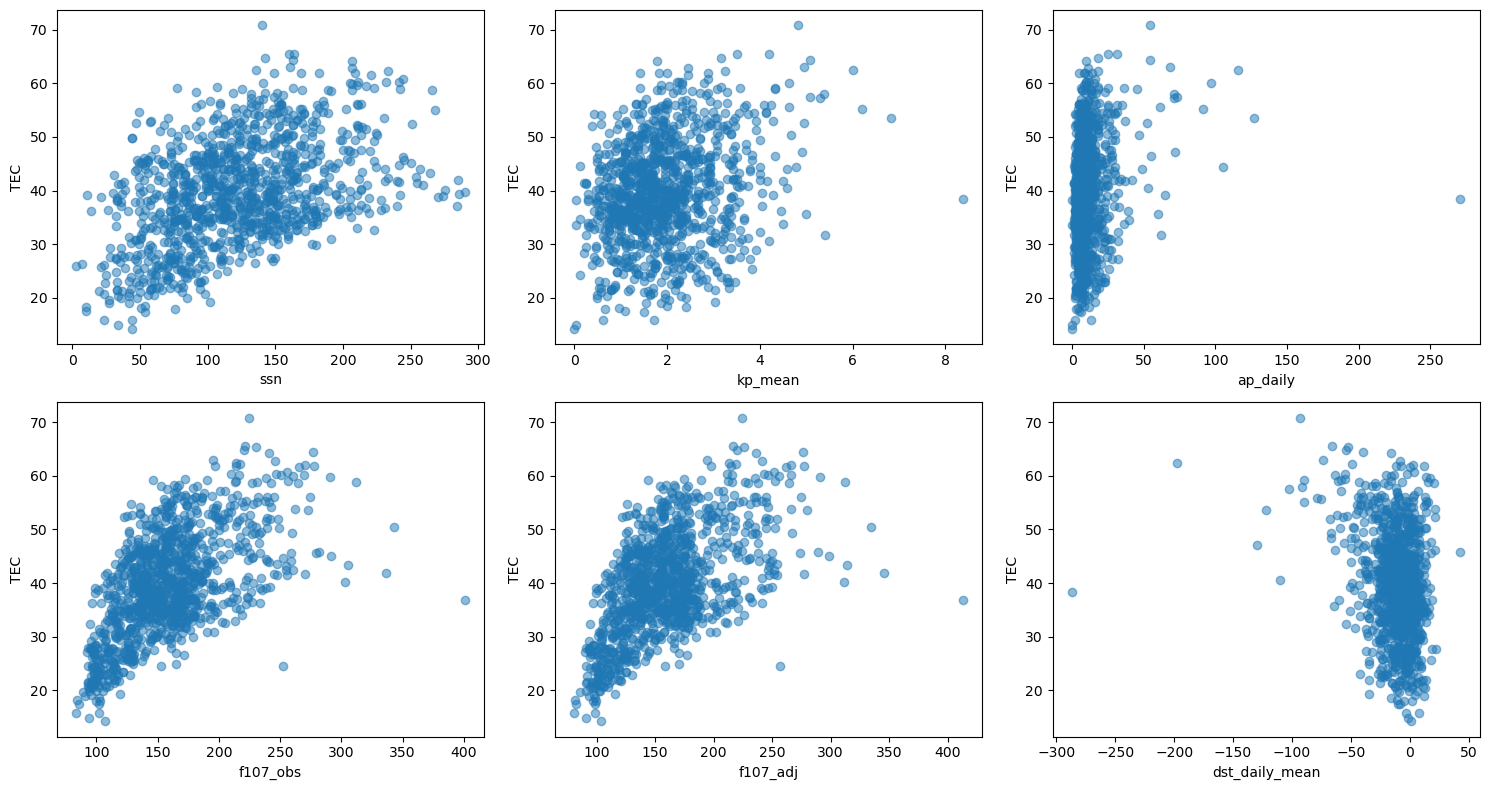

In [19]:
fig, axes = plt.subplots(2,3, figsize=(15,8))

axes = axes.flatten()

for ax, var in zip(axes, variables):

    temp = df[["daily_mean_tec", var]].dropna()

    ax.scatter(
        temp[var],
        temp["daily_mean_tec"],
        alpha=0.5
    )

    ax.set_xlabel(var)

    ax.set_ylabel("TEC")

plt.tight_layout()

plt.savefig(
    "../results/scatter_relationships.png",
    dpi=300
)

plt.show()

# One Way ANOVA

In [22]:
df["tec_group"] = pd.qcut(
    df["daily_mean_tec"],
    4,
    labels=False
)

groups = []

for i in range(4):

    groups.append(
        df[df["tec_group"] == i]["daily_mean_tec"]
    )

F, p = f_oneway(*groups)

print("One-Way ANOVA")

print("F Statistic:", F)

print("p-value:", p)

One-Way ANOVA
F Statistic: 2454.280188303086
p-value: 0.0


# Season Assignment

In [25]:
def season(month):

    if month in [12,1,2]:
        return "Dry"

    elif month in [3,4,5]:
        return "Pre-Rainy"

    elif month in [6,7,8]:
        return "Rainy"

    else:
        return "Post-Rainy"

df["season"] = df["date"].dt.month.apply(season)

df.head()

,date,daily_mean_tec,ssn,kp_mean,ap_daily,f107_obs,f107_adj,dst_daily_mean,tec_group,season
0,2022-01-01,19.980,48.0,2.416625,12.0,93.9,90.8,-11.125000,0,Dry
1,2022-01-02,19.680,27.0,2.041500,9.0,89.0,86.0,-9.708333,0,Dry
2,2022-01-03,18.256,10.0,2.416625,12.0,84.0,81.3,-10.833333,0,Dry
3,2022-01-04,17.548,10.0,1.083250,5.0,85.5,82.7,-10.083333,0,Dry
4,2022-01-05,15.896,23.0,0.625000,2.0,83.7,81.0,-3.583333,0,Dry


# Seasonal ANOVA

In [28]:
dry = df[df["season"]=="Dry"]["daily_mean_tec"]

pre = df[df["season"]=="Pre-Rainy"]["daily_mean_tec"]

rainy = df[df["season"]=="Rainy"]["daily_mean_tec"]

post = df[df["season"]=="Post-Rainy"]["daily_mean_tec"]

F, p = f_oneway(
    dry,
    pre,
    rainy,
    post
)

print("Seasonal ANOVA")

print("F Statistic:", F)

print("p-value:", p)

Seasonal ANOVA
F Statistic: 117.69627231862218
p-value: 4.827345395717322e-66


# Monthly TEC variation

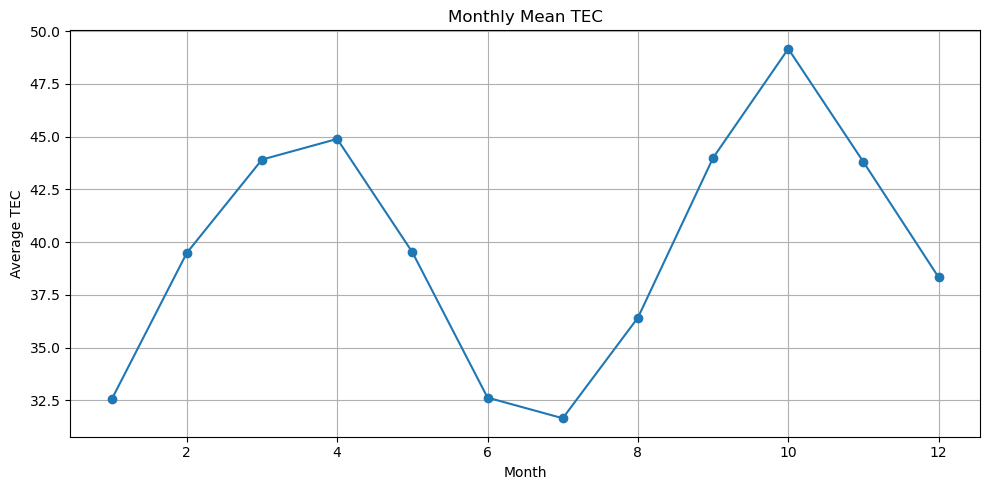

In [31]:
monthly = (
    df.groupby(df["date"].dt.month)["daily_mean_tec"]
      .mean()
)

plt.figure(figsize=(10,5))

monthly.plot(
    marker="o"
)

plt.xlabel("Month")

plt.ylabel("Average TEC")

plt.title("Monthly Mean TEC")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "../results/monthly_mean_tec.png",
    dpi=300
)

plt.show()

# Seasonal TEC boxplot

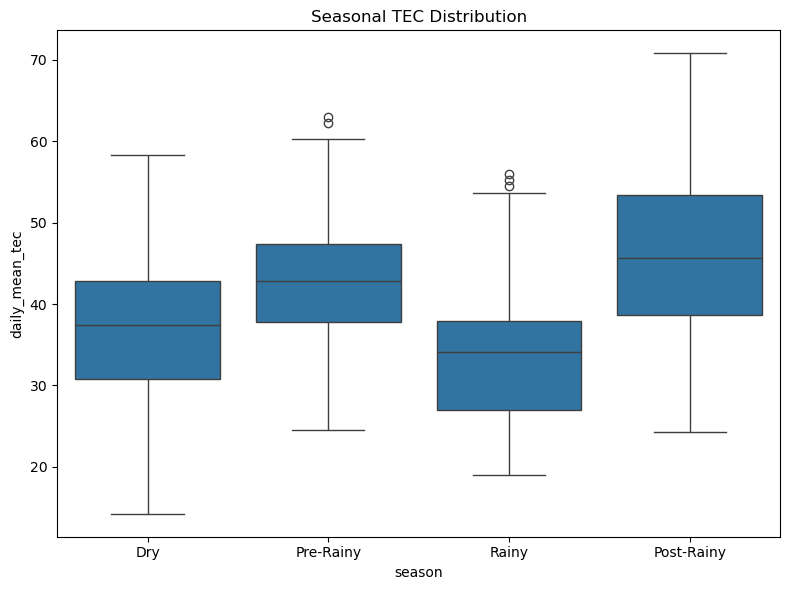

In [34]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="season",
    y="daily_mean_tec",
    data=df
)

plt.title("Seasonal TEC Distribution")

plt.tight_layout()

plt.savefig(
    "../results/seasonal_boxplot.png",
    dpi=300
)

plt.show()

# Export results

In [37]:
pearson_df.to_csv(
    "../results/pearson_results.csv",
    index=False
)

spearman_df.to_csv(
    "../results/spearman_results.csv",
    index=False
)

print("Statistical analysis completed successfully.")

Statistical analysis completed successfully.
